In [1]:
#載入模型
import os
from keras.models import load_model
import numpy as np
import xarray as xr
import shutil
from dateutil import parser
import pandas as pd
from datetime import datetime, timedelta
ROOT = "./"
model = ROOT + "model_West_241220.h5"
model = load_model(model)

2025-01-11 21:32:45.352630: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 21:32:45.554896: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-01-11 21:32:45.554921: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2025-01-11 21:32:45.590589: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-11 21:32:46.592258: W tensorflow/stream_executor/platform/de

In [2]:
ref_avg_std = pd.read_csv('./ref_avg_std.csv', index_col=0)

In [3]:
"""
0 temperature_2m_max
1 temperature_2m_mean
2 temperature_2m_min
3 relativehumidity_2m_max
4 relativehumidity_2m_mean
5 relativehumidity_2m_min
6 precipitation_max
7 precipitation_mean
8 precipitation_min
9 u_max
10 u_mean
11 u_min
12 v_max
13 v_mean
14 v_min


原始氣象資料尺寸 (1310, 31, 15)
輸入資料是[(None, 19, 15)] 
x_train_selected = x_train[:, 8:27, :]
代表使用的資料是從第9個特徵到第27個特徵

"""

#做一個(31,15)的numpy，裡面填流水號，讓我練習操作
import numpy as np
a = np.arange(1, 32).reshape(31, 1)
a = np.tile(a, 15)
a = a.reshape(31, 15)
print(a)
print(a[8:27,:]) #取出第9個特徵到第27個特徵

[[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
 [ 2  2  2  2  2  2  2  2  2  2  2  2  2  2  2]
 [ 3  3  3  3  3  3  3  3  3  3  3  3  3  3  3]
 [ 4  4  4  4  4  4  4  4  4  4  4  4  4  4  4]
 [ 5  5  5  5  5  5  5  5  5  5  5  5  5  5  5]
 [ 6  6  6  6  6  6  6  6  6  6  6  6  6  6  6]
 [ 7  7  7  7  7  7  7  7  7  7  7  7  7  7  7]
 [ 8  8  8  8  8  8  8  8  8  8  8  8  8  8  8]
 [ 9  9  9  9  9  9  9  9  9  9  9  9  9  9  9]
 [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]
 [11 11 11 11 11 11 11 11 11 11 11 11 11 11 11]
 [12 12 12 12 12 12 12 12 12 12 12 12 12 12 12]
 [13 13 13 13 13 13 13 13 13 13 13 13 13 13 13]
 [14 14 14 14 14 14 14 14 14 14 14 14 14 14 14]
 [15 15 15 15 15 15 15 15 15 15 15 15 15 15 15]
 [16 16 16 16 16 16 16 16 16 16 16 16 16 16 16]
 [17 17 17 17 17 17 17 17 17 17 17 17 17 17 17]
 [18 18 18 18 18 18 18 18 18 18 18 18 18 18 18]
 [19 19 19 19 19 19 19 19 19 19 19 19 19 19 19]
 [20 20 20 20 20 20 20 20 20 20 20 20 20 20 20]
 [21 21 21 21 21 21 21 21 21 21 21 21 21

In [5]:
import math
def fetch_openmeteo_archive(lat=23.5948,lon=120.442,start="2014-02-12",end="2014-04-08"):
    OPEN_METEO_API = "https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start}&end_date={end}&hourly=temperature_2m,relativehumidity_2m,precipitation,windspeed_10m,winddirection_10m&timezone=Asia%2FSingapore"
    url = OPEN_METEO_API.format(lat=lat,lon=lon,start=start,end=end)
    df = pd.read_json(url)
    df_obs = pd.DataFrame()
    for index, row in df.iterrows():
        df_obs[index] = row['hourly']
    df_obs['time'] = pd.to_datetime(df_obs['time'])
    #Calculate u, v wind components
    df_obs['u'] = df_obs['windspeed_10m'] * df_obs['winddirection_10m'].apply(lambda x: math.cos(math.radians(270-x)))
    df_obs['v'] = df_obs['windspeed_10m'] * df_obs['winddirection_10m'].apply(lambda x: math.sin(math.radians(270-x)))
    #移除有NaN的資料
    df_obs = df_obs.dropna()
    return df_obs

def fetch_openmeteo_forecast(lat=23.5948, lon=120.442, past_days=7, forecast_days=16):
    OPEN_METEO_API = "https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&hourly=temperature_2m,relativehumidity_2m,precipitation,windspeed_10m,winddirection_10m&past_days={past_days}&forecast_days={forecast_days}&models=ecmwf_aifs025&timezone=Asia%2FSingapore"
    url = OPEN_METEO_API.format(lat=lat,lon=lon,past_days=past_days,forecast_days=forecast_days)
    df = pd.read_json(url)
    df_forecast = pd.DataFrame()
    for index, row in df.iterrows():
        df_forecast[index] = row['hourly']
    df_forecast['time'] = pd.to_datetime(df_forecast['time'])
    #Calculate u, v wind components
    df_forecast['u'] = df_forecast['windspeed_10m'] * df_forecast['winddirection_10m'].apply(lambda x: math.cos(math.radians(270-x)))
    df_forecast['v'] = df_forecast['windspeed_10m'] * df_forecast['winddirection_10m'].apply(lambda x: math.sin(math.radians(270-x)))
    #移除有NaN的資料
    df_forecast = df_forecast.dropna()
    return df_forecast
def daily_and_normalization(ref_avg_std, df):
    for col in df.columns:
        if col == 'time':
            continue
        df[col] = ((df[col] - ref_avg_std[col]['mean']) / ref_avg_std[col]['std'])
    #Calculate daily stat
    #temperature_2m	relativehumidity_2m	precipitation	windspeed_10m	winddirection_10m	u	v
    df['time'] = pd.to_datetime(df['time'])
    df_daily_mean = df[['time', 'temperature_2m', 'relativehumidity_2m', 'precipitation', 'u', 'v']].resample('D', on='time').mean()
    df_daily_max = df[['time', 'temperature_2m', 'relativehumidity_2m', 'precipitation', 'u', 'v']].resample('D', on='time').max()
    df_daily_min = df[['time', 'temperature_2m', 'relativehumidity_2m', 'precipitation', 'u', 'v']].resample('D', on='time').min()
    #Append max, mean, min, to  columns name
    df_daily_mean.columns = [col + '_mean' for col in df_daily_mean.columns]
    df_daily_max.columns = [col + '_max' for col in df_daily_max.columns]
    df_daily_min.columns = [col + '_min' for col in df_daily_min.columns]
    df_daily = pd.concat([df_daily_mean,df_daily_max,df_daily_min],axis=1)
    #Re order columns
    df_daily = df_daily[[
        'temperature_2m_max',
        'temperature_2m_mean',
        'temperature_2m_min', 
        'relativehumidity_2m_max',
        'relativehumidity_2m_mean',
        'relativehumidity_2m_min',
        'precipitation_max', 
        'precipitation_mean',
        'precipitation_min', 
        'u_max',                  
        'u_mean',
        'u_min',
        'v_max',
        'v_mean',
        'v_min',
        ]]
    return df_daily

In [6]:
lat = 23.5948
lon = 120.442
past_days_start = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")
past_days_end = datetime.now().strftime("%Y-%m-%d")
#從archive跟forecast取得氣象資料
#archive是過去的資料，forecast是未來的資料，然後將兩個資料合併，archive的優先，因為他是真實的資料
weather_df_archive = fetch_openmeteo_archive(lat=lat,lon=lon,start=past_days_start,end=past_days_end)
weather_df_forecast = fetch_openmeteo_forecast(lat=lat,lon=lon)
weather_df = pd.concat([weather_df_archive, weather_df_forecast])
weather_df = weather_df.drop_duplicates(subset=['time'])


In [7]:
df_daily = daily_and_normalization(ref_avg_std, weather_df)
#做一個slide window，輸入資料是輸入資料是[(None, 19, 15)] ，所以每19天time step是一個資料
x = []
x_metadata = []
for i in range(0, len(df_daily)-19):
    x_metadata.append(df_daily.index[i+19]+timedelta(days=4))
    x.append(df_daily.iloc[i:i+19].values)
x = np.array(x)

In [8]:
#預測
y = model.predict(x)

12/12 [==============================] - 1s 11ms/step


[Text(19757.0, 0, '2024-02-04'),
 Text(19771.0, 0, '2024-02-18'),
 Text(19785.0, 0, '2024-03-03'),
 Text(19799.0, 0, '2024-03-17'),
 Text(19813.0, 0, '2024-03-31'),
 Text(19827.0, 0, '2024-04-14'),
 Text(19841.0, 0, '2024-04-28'),
 Text(19855.0, 0, '2024-05-12'),
 Text(19869.0, 0, '2024-05-26'),
 Text(19883.0, 0, '2024-06-09'),
 Text(19897.0, 0, '2024-06-23'),
 Text(19911.0, 0, '2024-07-07'),
 Text(19925.0, 0, '2024-07-21'),
 Text(19939.0, 0, '2024-08-04'),
 Text(19953.0, 0, '2024-08-18'),
 Text(19967.0, 0, '2024-09-01'),
 Text(19981.0, 0, '2024-09-15'),
 Text(19995.0, 0, '2024-09-29'),
 Text(20009.0, 0, '2024-10-13'),
 Text(20023.0, 0, '2024-10-27'),
 Text(20037.0, 0, '2024-11-10'),
 Text(20051.0, 0, '2024-11-24'),
 Text(20065.0, 0, '2024-12-08'),
 Text(20079.0, 0, '2024-12-22'),
 Text(20093.0, 0, '2025-01-05'),
 Text(20107.0, 0, '2025-01-19')]

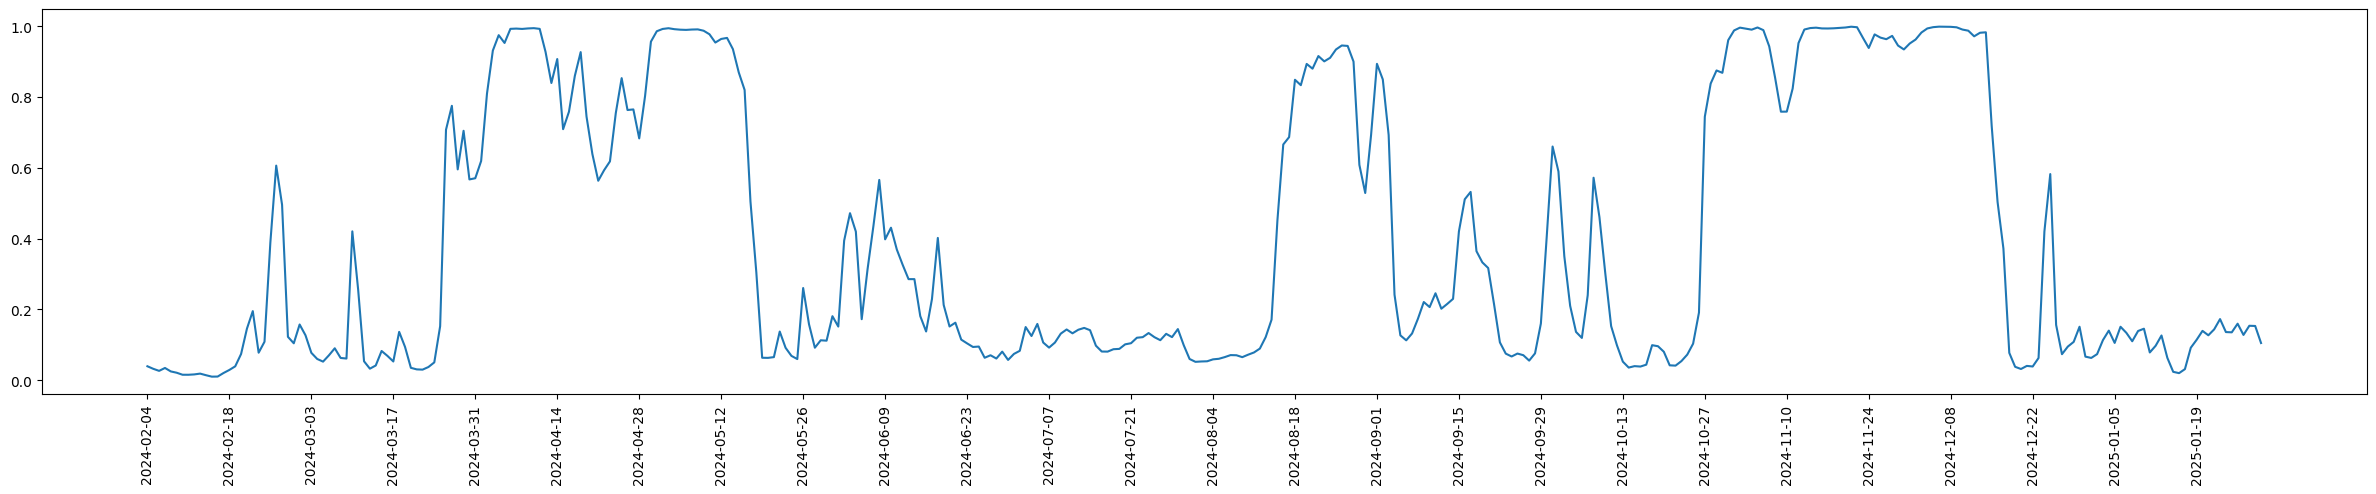

In [9]:
#把預測結果畫出來

import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,1,figsize=(30,5))
ax.plot(x_metadata, y, label='Predict')

#x軸每兩周顯示一次
ax.set_xticks(x_metadata[::14])
ax.set_xticklabels([str(x)[0:10] for x in x_metadata[::14]], rotation=90)

# Use downloaded weather data to make predictions

In [40]:
import pandas as pd

ERA5_archive = "../../ERA5_data _20230212_20250111"
skip = 0
x = []
x_metadata = []
for f in os.scandir(ERA5_archive):
    if skip >0:
        skip -= 1
        continue
    if f.name.endswith('.csv'):
        #12J990_口湖工作站_23.589978_120.180394.csv
        sta_no, sta_name, lat, lon = f.name.replace('.csv', '').split('_')
        print(f"Processing {f.name}")
        df_wea = pd.read_csv(f.path)
        #Keep only needed columns
        #temperature_2m	relativehumidity_2m		precipitation		windspeed_10m	winddirection_10m	Wu	Wv
        try:
            df_wea = df_wea[['time', 'temperature_2m', 'relativehumidity_2m', 'precipitation', 'Wu', 'Wv']]
            #Change Wu, Wv to u, v
            df_wea['u'] = df_wea['Wu']
            df_wea['v'] = df_wea['Wv']
            #Remove Wu, Wv
            df_wea = df_wea.drop(columns=['Wu', 'Wv'])
        except:
            pass
        df_daily = daily_and_normalization(ref_avg_std, df_wea)
        #做一個slide window，輸入資料是輸入資料是[(None, 19, 15)] ，所以每19天time step是一個資料
        for i in range(0, len(df_daily)-19):
            #站號,站名,日期,lat,lon
            x_metadata.append({"日期":df_daily.index[i+19]+timedelta(days=4), "lat":lat, "lon":lon, "站號":sta_no, "站名":sta_name})
            x.append(df_daily.iloc[i:i+19].values)
x = np.array(x)

Processing C0R710_龍磐_21.931672_120.838942.csv
Processing C1F9D1_白毛台_24.158325_120.886933.csv
Processing C0G940_竹塘_23.848253_120.386764.csv
Processing 467590_恆春_22.003897_120.746339.csv
Processing C1O850_環湖_23.148617_120.418633.csv
Processing C0U710_太平山_24.505486_121.525656.csv
Processing C0E820_獅潭_24.539133_120.920042.csv
Processing C0V880_興達_22.8778_120.2127.csv
Processing C0S890_關山_23.0395_121.175017.csv
Processing K2F750_種苗繁殖_24.225972_120.800917.csv
Processing C1Z130_銅門_23.965694_121.492842.csv
Processing C0AD40_土城_24.973208_121.445169.csv
Processing CAN140_六官養殖協會_23.22881_120.29962.csv
Processing C0X180_山上_23.0757_120.363253.csv
Processing C0F9Z0_雪山東峰_24.388792_121.268675.csv
Processing C1M480_獨立山_23.537022_120.607797.csv
Processing C0X220_學甲_23.230367_120.182187.csv
Processing C0R170_屏東_22.660269_120.494072.csv
Processing 467650_日月潭_23.881325_120.90805.csv
Processing C0K600_箔子寮_23.6197_120.14.csv
Processing C0G830_埤頭_23.866003_120.452806.csv
Processing C0S950_七塊厝_22.954453_121.22

In [41]:
#預測
y = model.predict(x)

    6/15983 [..............................] - ETA: 2:40 

2025-01-12 15:25:35.067480: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 583031340 exceeds 10% of free system memory.


15983/15983 [==============================] - 176s 11ms/step


In [42]:
#把預報結果存成各自的csv
for i in range(len(x_metadata)):
    #站號,站名,日期,lat,lon
    sta_no = x_metadata[i]["站號"]
    sta_name = x_metadata[i]["站名"]
    lat = x_metadata[i]["lat"]
    lon = x_metadata[i]["lon"]
    date = x_metadata[i]["日期"]
    prediction = str(round(y[i][0],2))
    #"../../rice_blast_prediction/data/20120111_BlastLSTLS.csv"
    csv_path = f"../../rice_blast_prediction/data/{date.strftime('%Y%m%d')}_BlastLSTS.csv"
    if not os.path.exists(csv_path):
        df = pd.DataFrame(columns=['站號', '站名', '日期', 'lat', 'lon', 'BlastLSTLS'])
        #Put data into dataframe
        df.loc[0] = [sta_no, sta_name, date, lat, lon, prediction]
    else:
        df = pd.read_csv(csv_path)
        df.loc[len(df)] = [sta_no, sta_name, date, lat, lon, prediction]
    #print(f"Prediction for {sta_no}_{sta_name}_{date}, lat:{lat}, lon:{lon}, prediction:{prediction}")
    #Check there is no duplicate row in the csv
    df = df.drop_duplicates()
    #Save to
    df.to_csv(csv_path, index=False)